<a href="https://colab.research.google.com/github/farhanbin65/AI-chatbot-using-Groq-API/blob/main/02_Baseline_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Baseline Models
## Elliptic Bitcoin Fraud Detection
**Goal:** Train and compare 4 baseline models (Logistic Regression, Random Forest, XGBoost, LightGBM) on the Elliptic dataset using temporal split and 48/52 class weighting.

In [2]:
# Mount Drive and load processed data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

SAVE_PATH = '/content/drive/MyDrive/CryptoFraud/'

# Load processed data from Notebook 1
df_labelled = pd.read_parquet(SAVE_PATH + 'df_labelled.parquet')
edges       = pd.read_parquet(SAVE_PATH + 'edges.parquet')

with open(SAVE_PATH + 'feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("Loaded successfully:")
print(f"  df_labelled:  {len(df_labelled):,} rows")
print(f"  edges:        {len(edges):,} edges")
print(f"  feature_cols: {len(feature_cols)} features")
print(f"  Time steps:   {df_labelled['time_step'].min()} to {df_labelled['time_step'].max()}")
print(f"  Illicit:      {df_labelled['label'].sum():,} ({df_labelled['label'].mean()*100:.1f}%)")
print(f"  Licit:        {(df_labelled['label']==0).sum():,} ({(df_labelled['label']==0).mean()*100:.1f}%)")

Mounted at /content/drive
Loaded successfully:
  df_labelled:  46,564 rows
  edges:        234,355 edges
  feature_cols: 165 features
  Time steps:   1 to 49
  Illicit:      4,545 (9.8%)
  Licit:        42,019 (90.2%)


## Step 2 — Temporal Split and Class Weighting

In [3]:
# ── Temporal split ─────────────────────────────────────────────────────
# Train: steps 1-27 (~80%)
# Test:  steps 28-49 (~20%)
split_step = 27

train_df = df_labelled[df_labelled['time_step'] <= split_step].copy()
test_df  = df_labelled[df_labelled['time_step'] >  split_step].copy()

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

# ── 48/52 class weights ────────────────────────────────────────────────
n_illicit = y_train.sum()
n_licit   = (y_train == 0).sum()
n_total   = len(y_train)

weight_illicit       = (0.48 * n_total) / n_illicit
weight_licit         = (0.52 * n_total) / n_licit
weight_dict          = {1: weight_illicit, 0: weight_licit}
scale_pos_weight     = weight_illicit / weight_licit
sample_weights_train = np.where(y_train == 1, weight_illicit, weight_licit)

# ── Verify ─────────────────────────────────────────────────────────────
assert X_train.shape[0] > 0, "X_train empty"
assert X_test.shape[0]  > 0, "X_test empty"
assert np.isnan(X_train).sum() == 0, "NaNs in X_train"
assert np.isnan(X_test).sum()  == 0, "NaNs in X_test"

print("Temporal Split:")
print(f"  Train: steps 1-{split_step}   → {len(train_df):,} rows")
print(f"    Illicit: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"    Licit:   {(y_train==0).sum():,} ({(1-y_train.mean())*100:.1f}%)")
print(f"\n  Test:  steps {split_step+1}-49 → {len(test_df):,} rows")
print(f"    Illicit: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"    Licit:   {(y_test==0).sum():,} ({(1-y_test.mean())*100:.1f}%)")
print(f"\n48/52 Class Weights:")
print(f"  Licit weight:   {weight_licit:.4f}")
print(f"  Illicit weight: {weight_illicit:.4f}")
print(f"  Ratio:          1 : {scale_pos_weight:.2f}")
print(f"\nAll checks passed — ready to train")

Temporal Split:
  Train: steps 1-27   → 24,923 rows
    Illicit: 2,457 (9.9%)
    Licit:   22,466 (90.1%)

  Test:  steps 28-49 → 21,641 rows
    Illicit: 2,088 (9.6%)
    Licit:   19,553 (90.4%)

48/52 Class Weights:
  Licit weight:   0.5769
  Illicit weight: 4.8690
  Ratio:          1 : 8.44

All checks passed — ready to train


## Step 3 — Train Baseline Models

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, precision_score, recall_score)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight=weight_dict,
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight=weight_dict,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        class_weight=weight_dict,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")

    if name == 'Logistic Regression':
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train,
                  sample_weight=sample_weights_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc       = roc_auc_score(y_test, y_proba)
    f1_ill    = f1_score(y_test, y_pred, pos_label=1)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall    = recall_score(y_test, y_pred, pos_label=1)
    cm        = confusion_matrix(y_test, y_pred)
    fpr       = cm[0][1] / (cm[0][1] + cm[0][0])

    results[name] = {
        'AUC-ROC':          auc,
        'F1 (Illicit)':     f1_ill,
        'Precision':        precision,
        'Recall':           recall,
        'FPR':              fpr,
        'Confusion Matrix': cm,
        'y_pred':           y_pred,
        'y_proba':          y_proba
    }

    print(f"  AUC:  {auc:.4f} | F1: {f1_ill:.4f} | "
          f"Prec: {precision:.4f} | Recall: {recall:.4f} | FPR: {fpr:.4f}")

# ── Results table ──────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Model':<22} {'AUC':>6} {'F1-Ill':>8} {'Prec':>7} {'Recall':>8} {'FPR':>7}")
print("="*65)
for name, r in results.items():
    print(f"{name:<22} {r['AUC-ROC']:>6.4f} {r['F1 (Illicit)']:>8.4f} "
          f"{r['Precision']:>7.4f} {r['Recall']:>8.4f} {r['FPR']:>7.4f}")
print("="*65)

best_model = max(results, key=lambda x: results[x]['F1 (Illicit)'])
print(f"\nBest model: {best_model}")
print(f"  F1:  {results[best_model]['F1 (Illicit)']:.4f}")
print(f"  AUC: {results[best_model]['AUC-ROC']:.4f}")
print(f"  FPR: {results[best_model]['FPR']:.4f}")

Training Logistic Regression...
  AUC:  0.8412 | F1: 0.3249 | Prec: 0.1950 | Recall: 0.9737 | FPR: 0.4292
Training Random Forest...
  AUC:  0.9538 | F1: 0.7513 | Prec: 0.9937 | Recall: 0.6039 | FPR: 0.0004
Training XGBoost...
  AUC:  0.9457 | F1: 0.8161 | Prec: 0.8118 | Recall: 0.8204 | FPR: 0.0203
Training LightGBM...
  AUC:  0.9625 | F1: 0.8405 | Prec: 0.8472 | Recall: 0.8338 | FPR: 0.0161

Model                     AUC   F1-Ill    Prec   Recall     FPR
Logistic Regression    0.8412   0.3249  0.1950   0.9737  0.4292
Random Forest          0.9538   0.7513  0.9937   0.6039  0.0004
XGBoost                0.9457   0.8161  0.8118   0.8204  0.0203
LightGBM               0.9625   0.8405  0.8472   0.8338  0.0161

Best model: LightGBM
  F1:  0.8405
  AUC: 0.9625
  FPR: 0.0161


## Step 4 — Visualise Results

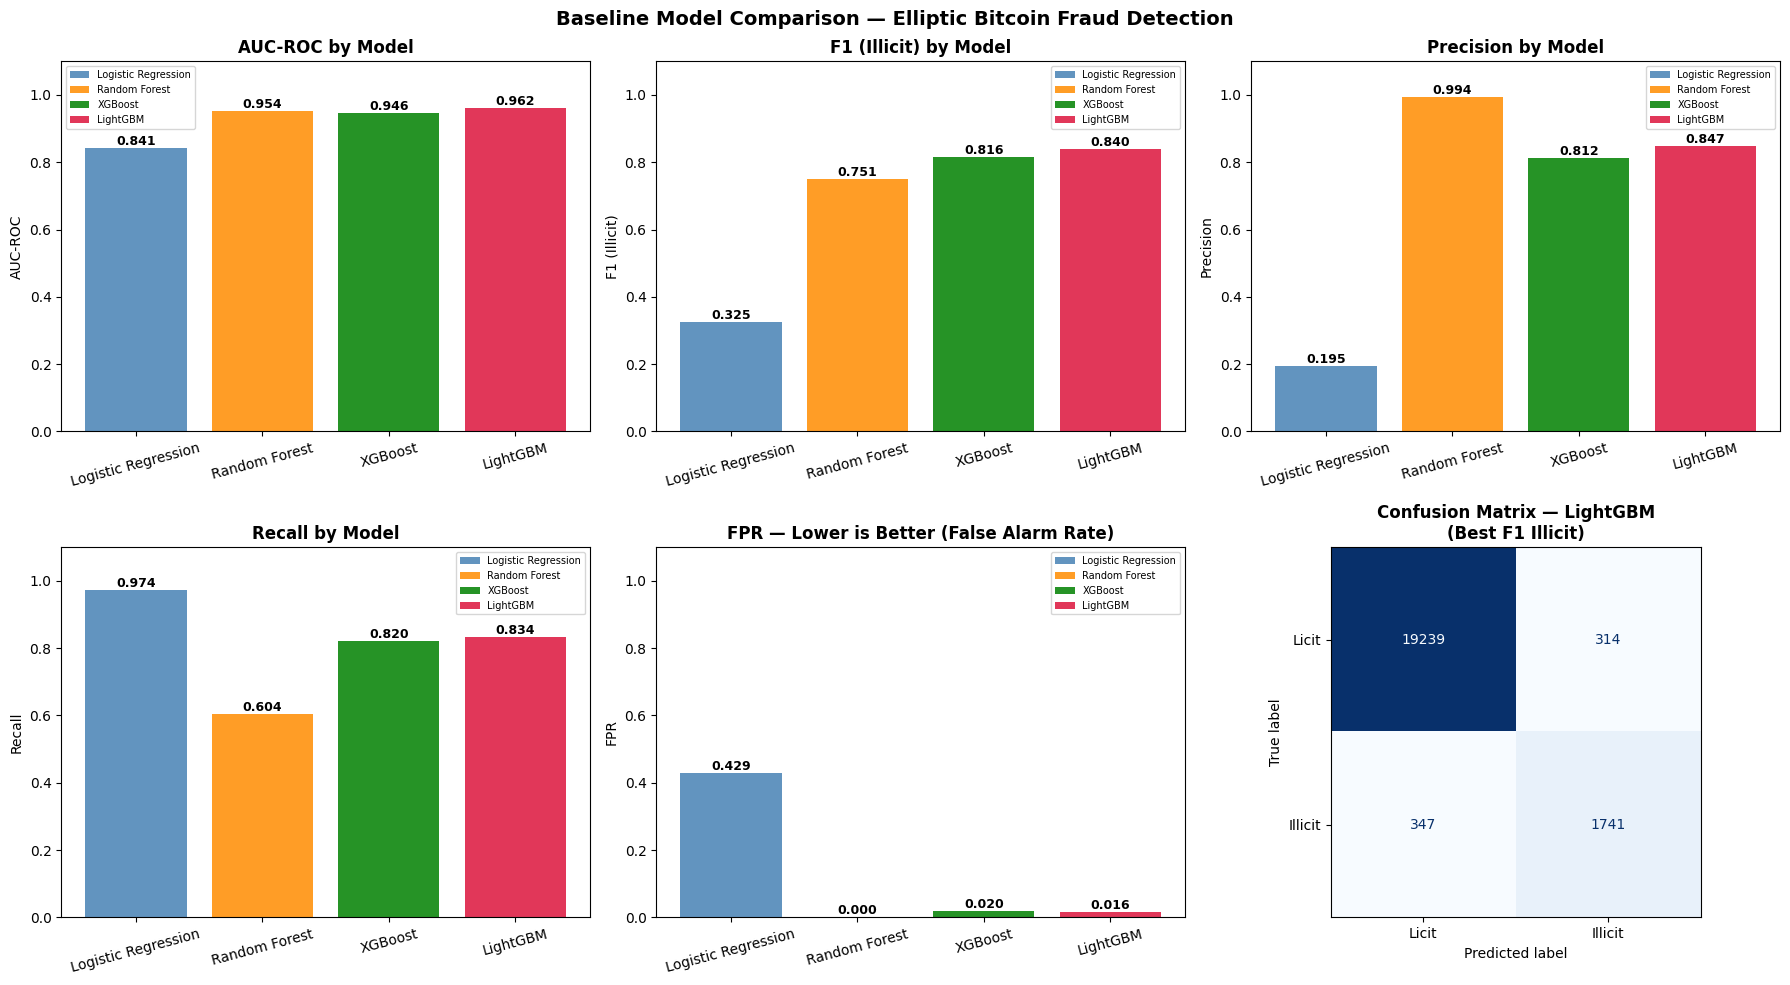

Confusion Matrix — LightGBM:
  True Licit   → Predicted Licit:    19,239  (correct)
  True Licit   → Predicted Illicit:  314  (false alarms)
  True Illicit → Predicted Licit:    347  (missed fraud)
  True Illicit → Predicted Illicit:  1,741  (caught fraud)

  Caught 1,741 of 2,088 illicit transactions
  False alarm rate: 1.6% of legitimate transactions wrongly blocked


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results.keys())
colors      = ['steelblue', 'darkorange', 'green', 'crimson']
metrics     = ['AUC-ROC', 'F1 (Illicit)', 'Precision', 'Recall', 'FPR']
metric_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, metric in zip(metric_axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85)
    ax.set_title(f'{metric} by Model', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for p, v in zip(bars, vals):
        ax.annotate(f'{v:.3f}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.legend(bars, model_names, fontsize=7)
    if metric == 'FPR':
        ax.set_title('FPR — Lower is Better (False Alarm Rate)',
            fontweight='bold')

# Confusion matrix — best model
cm   = results[best_model]['Confusion Matrix']
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['Licit', 'Illicit'])
disp.plot(ax=axes[1,2], colorbar=False, cmap='Blues')
axes[1,2].set_title(f'Confusion Matrix — {best_model}\n(Best F1 Illicit)',
    fontweight='bold')

plt.suptitle('Baseline Model Comparison — Elliptic Bitcoin Fraud Detection',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Read confusion matrix numbers
cm = results[best_model]['Confusion Matrix']
print(f"Confusion Matrix — {best_model}:")
print(f"  True Licit   → Predicted Licit:    {cm[0][0]:,}  (correct)")
print(f"  True Licit   → Predicted Illicit:  {cm[0][1]:,}  (false alarms)")
print(f"  True Illicit → Predicted Licit:    {cm[1][0]:,}  (missed fraud)")
print(f"  True Illicit → Predicted Illicit:  {cm[1][1]:,}  (caught fraud)")
print(f"\n  Caught {cm[1][1]:,} of {cm[1][0]+cm[1][1]:,} illicit transactions")
print(f"  False alarm rate: {cm[0][1]/(cm[0][0]+cm[0][1])*100:.1f}% of legitimate transactions wrongly blocked")

## Step 5 — Save Best Model

In [6]:
import joblib
import pickle

# Save best model
joblib.dump(models[best_model], SAVE_PATH + 'best_baseline_model.pkl')

# Save results without non-serialisable arrays
results_to_save = {
    name: {k: v for k, v in r.items()
           if k not in ['y_pred', 'y_proba', 'Confusion Matrix']}
    for name, r in results.items()
}
with open(SAVE_PATH + 'baseline_results.pkl', 'wb') as f:
    pickle.dump(results_to_save, f)

# Save test arrays for SHAP notebook
np.save(SAVE_PATH + 'X_train.npy', X_train)
np.save(SAVE_PATH + 'X_test.npy',  X_test)
np.save(SAVE_PATH + 'y_train.npy', y_train)
np.save(SAVE_PATH + 'y_test.npy',  y_test)
np.save(SAVE_PATH + 'sample_weights_train.npy', sample_weights_train)

with open(SAVE_PATH + 'weight_dict.pkl', 'wb') as f:
    pickle.dump(weight_dict, f)

print("Saved to Google Drive:")
print(f"  best_baseline_model.pkl  — {best_model}")
print(f"  baseline_results.pkl     — all 4 model metrics")
print(f"  X_train.npy              — {X_train.shape}")
print(f"  X_test.npy               — {X_test.shape}")
print(f"  y_train.npy              — {y_train.shape}")
print(f"  y_test.npy               — {y_test.shape}")
print(f"  weight_dict.pkl          — {weight_dict}")
print(f"\n02_Baseline_Models complete — open 03_GNN_GraphSAGE.ipynb next")

Saved to Google Drive:
  best_baseline_model.pkl  — LightGBM
  baseline_results.pkl     — all 4 model metrics
  X_train.npy              — (24923, 165)
  X_test.npy               — (21641, 165)
  y_train.npy              — (24923,)
  y_test.npy               — (21641,)
  weight_dict.pkl          — {1: np.float64(4.868962148962148), 0: np.float64(0.5768699367933767)}

02_Baseline_Models complete — open 03_GNN_GraphSAGE.ipynb next
